<a href="https://colab.research.google.com/github/ganesh10-code/DL_Lab/blob/main/Week_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11
23. Implement Auto Encoder model on MINIST dataset.
24. Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)
25. Implement Regularization in AE and demonstrate its use.
26. Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)
27. Demonstrate PCA with AE on a dataset.
28. Implement Sparse AE and Contractive AE.


2026-04-20 06:20:41.401663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776666041.631293      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776666041.690422      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776666042.185372      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666042.185418      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776666042.185422      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train Shape: (60000, 784)
Test Shape : (10000, 784)


2026-04-20 06:21:10.969042: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0942 - val_loss: 0.0374
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0338 - val_loss: 0.0255
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0244 - val_loss: 0.0207
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0205 - val_loss: 0.0185
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0186 - val_loss: 0.0170
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0171 - val_loss: 0.0158
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0161 - val_loss: 0.0150
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0152 - val_loss: 0.0142
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0144 - val_loss: 0.0135
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0137 - val_loss: 0.0138
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0132 - val_loss: 0.0124
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/ste

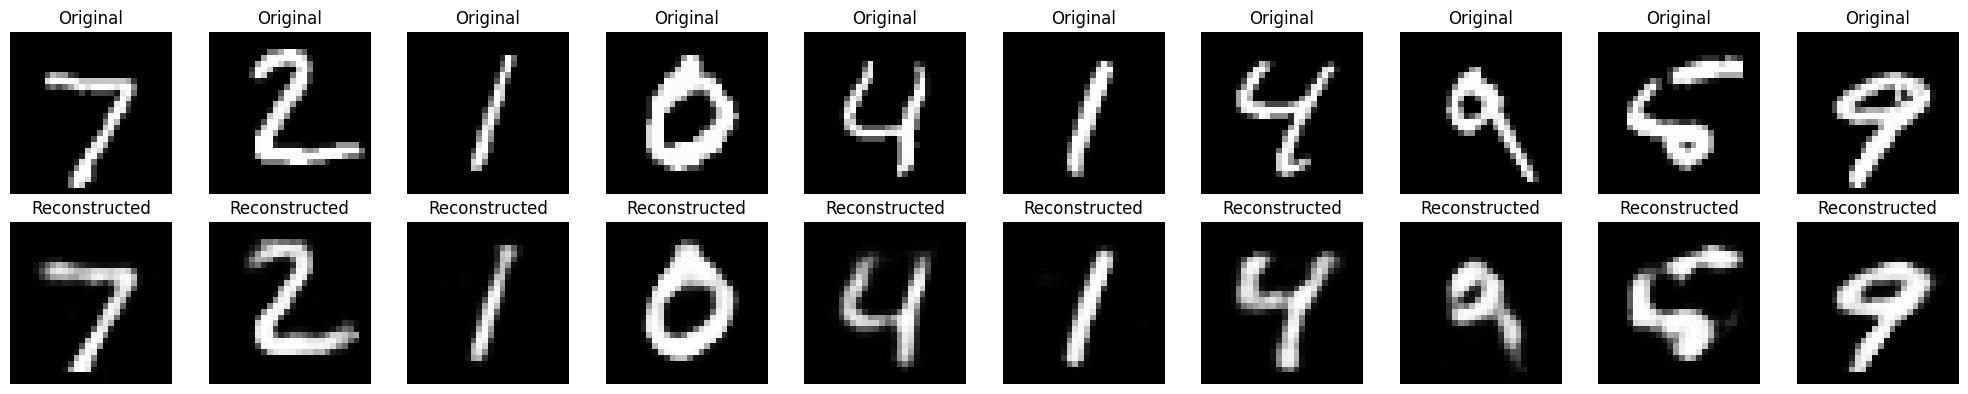

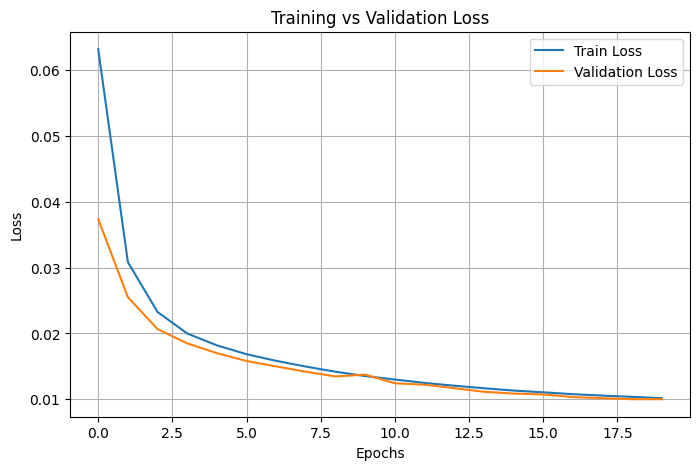

In [ ]:
#AutoEncoder model on MNIST

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. LOAD DATASET
(x_train, _), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten 28x28 -> 784
x_train = x_train.reshape(len(x_train), 784)
x_test  = x_test.reshape(len(x_test), 784)

print("Train Shape:", x_train.shape)
print("Test Shape :", x_test.shape)


# 2. BUILD AUTOENCODER MODEL
input_dim = 784
encoding_dim = 32

input_img = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent  = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output  = Dense(input_dim, activation='sigmoid')(decoded)

# Full Autoencoder
autoencoder = Model(input_img, output)

# Encoder model
encoder = Model(input_img, latent)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


# 3. TRAIN MODEL
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)



# 4. RECONSTRUCTION
reconstructed = autoencoder.predict(x_test)



# 5. EVALUATION METRICS

# Mean Squared Error
mse = mean_squared_error(x_test.flatten(), reconstructed.flatten())

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(x_test.flatten(), reconstructed.flatten())

# R2 Score
r2 = r2_score(x_test.flatten(), reconstructed.flatten())

# Peak Signal to Noise Ratio
psnr = 20 * np.log10(1.0 / rmse)

# Binary Crossentropy
bce = tf.keras.losses.binary_crossentropy(x_test, reconstructed).numpy().mean()

# Compression Ratio
compression_ratio = input_dim / encoding_dim

# Final losses
train_loss = history.history['loss'][-1]
val_loss   = history.history['val_loss'][-1]

print("\n================ EVALUATION METRICS ================\n")
print(f"Training Loss              : {train_loss:.6f}")
print(f"Validation Loss            : {val_loss:.6f}")
print(f"Mean Squared Error (MSE)   : {mse:.6f}")
print(f"Root Mean Squared Error    : {rmse:.6f}")
print(f"Mean Absolute Error (MAE)  : {mae:.6f}")
print(f"R2 Score                   : {r2:.6f}")
print(f"PSNR                       : {psnr:.2f} dB")
print(f"Binary Crossentropy        : {bce:.6f}")
print(f"Compression Ratio          : {compression_ratio:.2f}:1")


# 6. LATENT REPRESENTATION STATS
latent_vectors = encoder.predict(x_test)

print("\n=============== LATENT SPACE METRICS ===============\n")
print("Latent Shape               :", latent_vectors.shape)
print("Latent Mean               :", np.mean(latent_vectors))
print("Latent Std Dev            :", np.std(latent_vectors))
print("Latent Min                :", np.min(latent_vectors))
print("Latent Max                :", np.max(latent_vectors))


# 7. VISUALIZE ORIGINAL VS RECONSTRUCTED
n = 10
plt.figure(figsize=(20,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()


# 8. LOSS CURVE
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Training for latent = 4
Training for latent = 8
Training for latent = 16
Training for latent = 32
Training for latent = 64
Training for latent = 128
Training for latent = 512
Training for latent = 1024

Latent Dim | Compression | Loss | MSE
4 	    196.0 :1	 0.055176
8 	    98.0 :1	 0.023714
16 	    49.0 :1	 0.016342
32 	    24.5 :1	 0.013922
64 	    12.25 :1	 0.011488
128 	    6.12 :1	 0.010216
512 	    1.53 :1	 0.009763
1024 	    0.77 :1	 0.009474


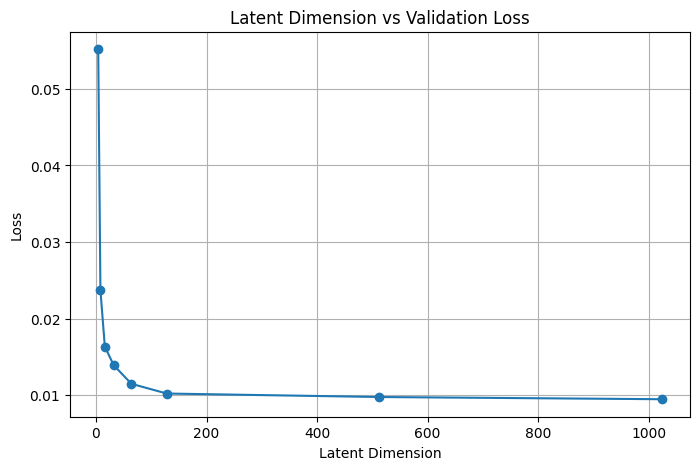

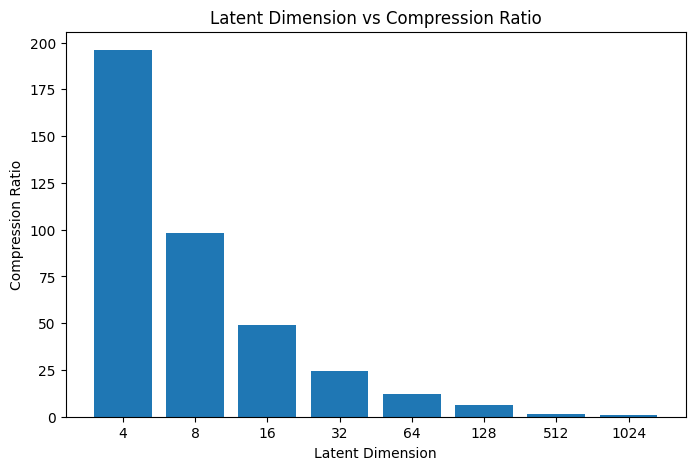

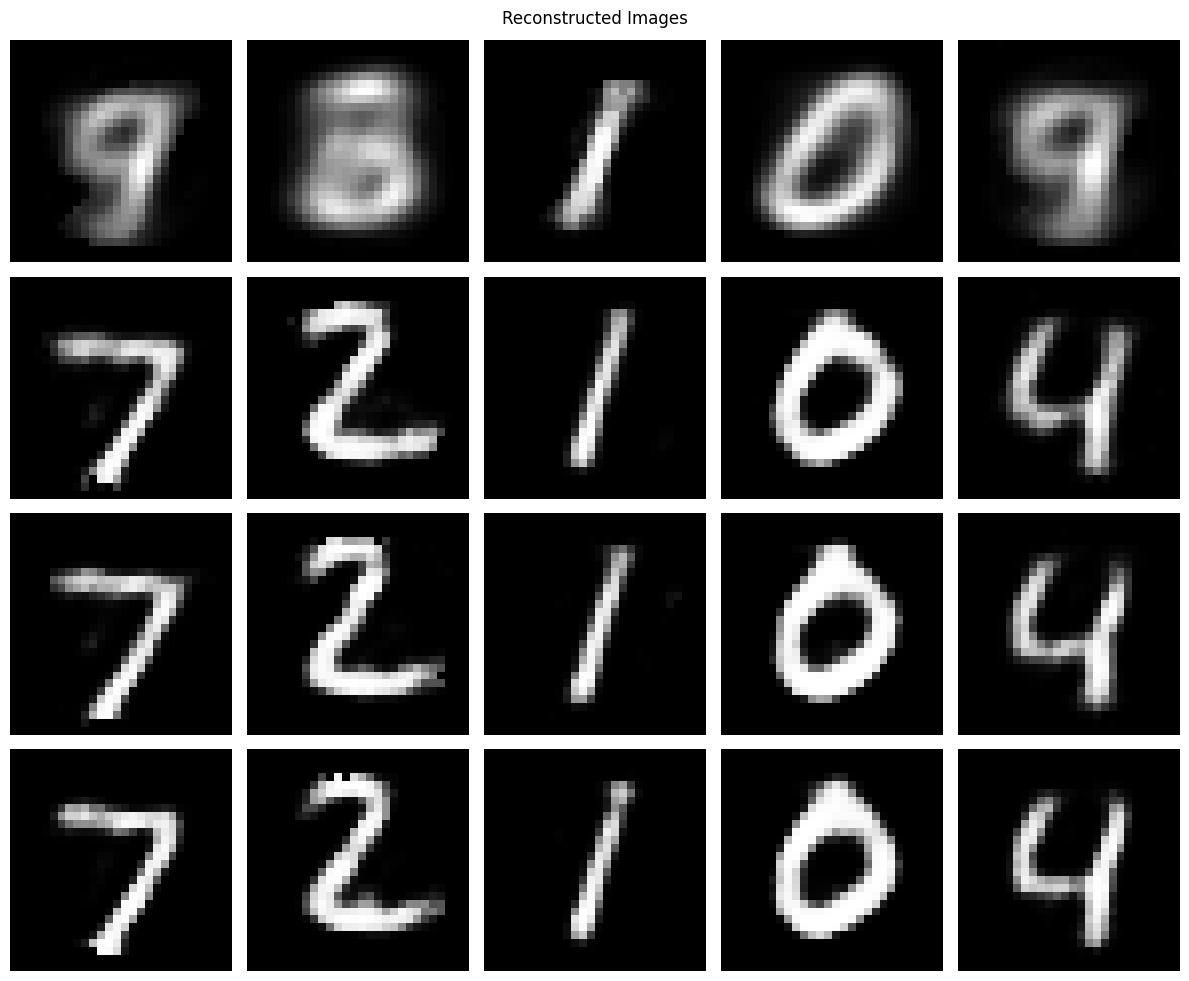

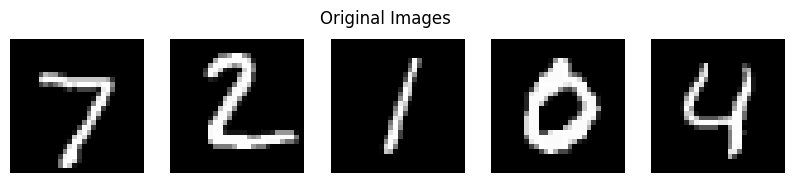

In [ ]:
# ===============================================================
# UNDERCOMPLETE AE vs OVERCOMPLETE AE ON MNIST
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# ===============================================================
# 1. LOAD DATA
# ===============================================================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(len(x_train), 784)
x_test  = x_test.reshape(len(x_test), 784)

# ===============================================================
# 2. FUNCTION TO BUILD MODEL
# ===============================================================
def build_autoencoder(latent_dim):

    inp = Input(shape=(784,))

    # Encoder
    x = Dense(256, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    latent = Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = Dense(128, activation='relu')(latent)
    x = Dense(256, activation='relu')(x)
    out = Dense(784, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')

    return model

# ===============================================================
# 3. TRAIN FOR DIFFERENT LATENT DIMENSIONS
# ===============================================================
latent_dims = [4, 8, 16, 32, 64, 128, 512, 1024]

loss_list = []
compression_list = []
models = {}

for dim in latent_dims:

    print("Training for latent =", dim)

    model = build_autoencoder(dim)

    history = model.fit(
        x_train, x_train,
        epochs=5,
        batch_size=256,
        validation_data=(x_test, x_test),
        verbose=0
    )

    # Reconstruction
    recon = model.predict(x_test, verbose=0)

    # Metrics
    loss = history.history['val_loss'][-1]
    compression = round(784 / dim, 2)

    loss_list.append(loss)
    compression_list.append(compression)

    models[dim] = model

# ===============================================================
# 4. TABLE OUTPUT
# ===============================================================
print("\n================================================")
print("Latent Dim | Compression | Loss | MSE")
print("================================================")

for i in range(len(latent_dims)):
    print(latent_dims[i], "\t   ",
          compression_list[i], ":1\t",
          round(loss_list[i],6))

# ===============================================================
# 5. LOSS GRAPH
# ===============================================================
plt.figure(figsize=(8,5))
plt.plot(latent_dims, loss_list, marker='o')
plt.title("Latent Dimension vs Validation Loss")
plt.xlabel("Latent Dimension")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ===============================================================
# 7. COMPRESSION GRAPH
# ===============================================================
plt.figure(figsize=(8,5))
plt.bar([str(i) for i in latent_dims], compression_list)
plt.title("Latent Dimension vs Compression Ratio")
plt.xlabel("Latent Dimension")
plt.ylabel("Compression Ratio")
plt.show()

# ===============================================================
# 8. RECONSTRUCTED IMAGES
# ===============================================================
sample_dims = [4, 32, 128, 1024]

plt.figure(figsize=(12,10))

for row, dim in enumerate(sample_dims):

    model = models[dim]
    recon = model.predict(x_test[:5], verbose=0)

    for col in range(5):

        ax = plt.subplot(len(sample_dims), 5, row*5 + col + 1)
        plt.imshow(recon[col].reshape(28,28), cmap='gray')
        plt.axis("off")

        if col == 0:
            plt.ylabel("Latent="+str(dim))

plt.suptitle("Reconstructed Images")
plt.tight_layout()
plt.show()

# ===============================================================
# 9. ORIGINAL IMAGES
# ===============================================================
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.suptitle("Original Images")
plt.show()

Train Shape : (60000, 784)
Test Shape  : (10000, 784)


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_180 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5436 - val_loss: 0.2849
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2668 - val_loss: 0.2344
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2310 - val_loss: 0.2200
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2184 - val_loss: 0.2101
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2096 - val_loss: 0.2030
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2021 - val_loss: 0.1977
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1972 - val_loss: 0.1934
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1934 - val_loss: 0.1901
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1900 - val_loss: 0.1873
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1878 - val_loss: 0.1847
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step

Test Loss   = 0.161638
MSE         = 0.030926
Compression = 24.5 :1


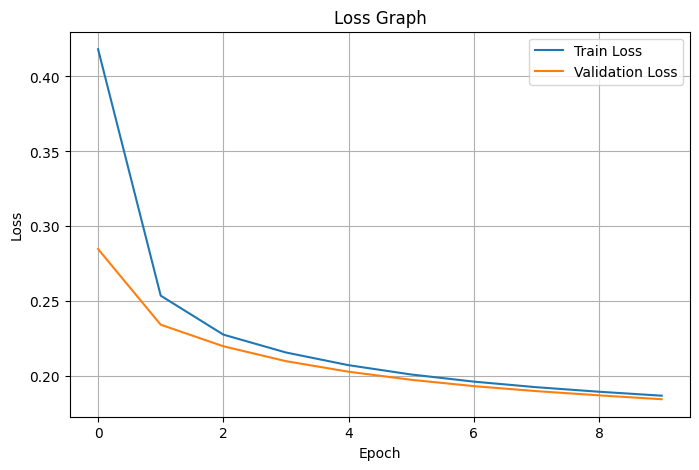

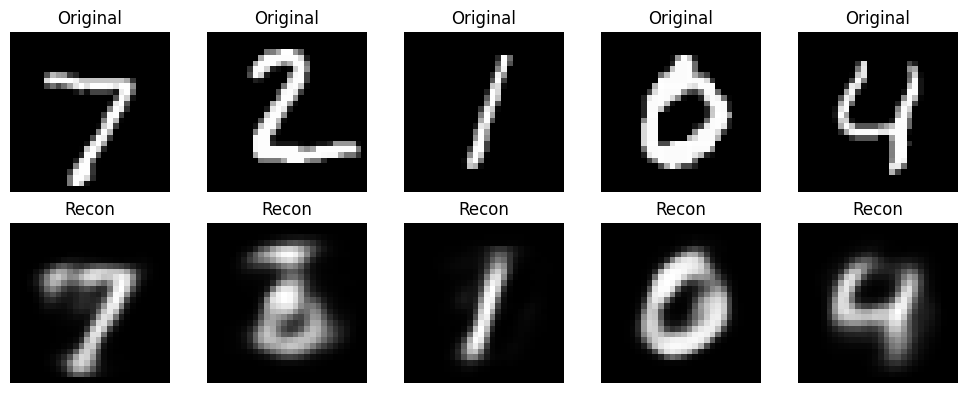

In [ ]:
# ==========================================================
# IMPLEMENTING REGULARIZATION IN AUTOENCODER
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# ==========================================================
# 1. LOAD DATA
# ==========================================================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and convert to float32
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print("Train Shape :", x_train.shape)
print("Test Shape  :", x_test.shape)

# ==========================================================
# 2. BUILD REGULARIZED AUTOENCODER
# ==========================================================
input_img = Input(shape=(784,))

# Encoder with L1 + L2 regularization
encoded = Dense(
    32,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-5),
    kernel_regularizer=regularizers.l2(1e-5)
)(input_img)

# Decoder
decoded = Dense(784, activation='sigmoid')(encoded)

# Model
autoencoder = Model(inputs=input_img, outputs=decoded)

# Compile
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

# ==========================================================
# 3. TRAIN MODEL
# ==========================================================
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

# ==========================================================
# 4. RECONSTRUCTION
# ==========================================================
reconstructed = autoencoder.predict(x_test)

# ==========================================================
# 5. METRICS
# ==========================================================
loss = autoencoder.evaluate(x_test, x_test, verbose=0)

mse = mean_squared_error(
    x_test.flatten(),
    reconstructed.flatten()
)

compression = round(784 / 32, 2)

print("\n==============================")
print("Test Loss   =", round(loss, 6))
print("MSE         =", round(mse, 6))
print("Compression =", compression, ":1")
print("==============================")

# ==========================================================
# 6. LOSS GRAPH
# ==========================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# 7. ORIGINAL vs RECONSTRUCTED
# ==========================================================
n = 5
plt.figure(figsize=(10,4))

for i in range(n):

    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i+n+1)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0914 - val_loss: 0.0399
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0369 - val_loss: 0.0300
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0295 - val_loss: 0.0264
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0262 - val_loss: 0.0243
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0244 - val_loss: 0.0234
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Noise Factor = 0.4
Reconstruction MSE = 0.023362


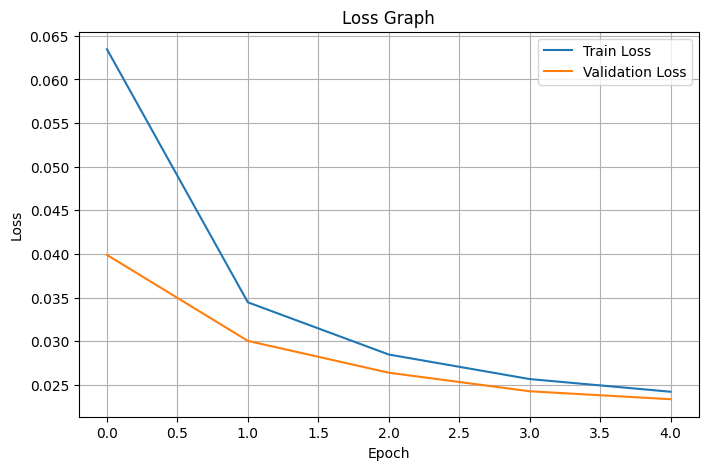

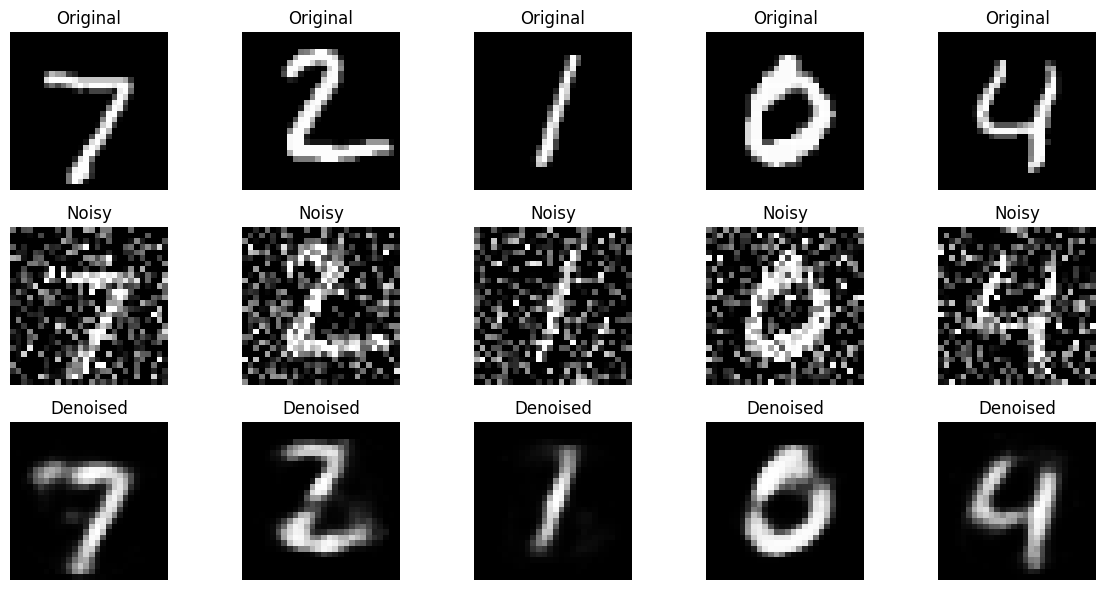

In [ ]:
# ==========================================================
# DENOISING AUTOENCODER ON MNIST
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import mean_squared_error

# ==========================================================
# 1. LOAD DATA
# ==========================================================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(60000, 784)
x_test  = x_test.reshape(10000, 784)

# ==========================================================
# 2. ADD NOISE
# ==========================================================
noise_factor = 0.40     # change: 0.1,0.2,0.4,0.6

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

# keep values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy, 0., 1.)

# ==========================================================
# 3. BUILD DENOISING AUTOENCODER
# ==========================================================
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# ==========================================================
# 4. TRAIN MODEL
# Input  = noisy image
# Output = clean image
# ==========================================================
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

# ==========================================================
# 5. PREDICT CLEANED IMAGE
# ==========================================================
decoded_imgs = autoencoder.predict(x_test_noisy)

# ==========================================================
# 6. METRICS
# ==========================================================
mse = mean_squared_error(x_test.flatten(), decoded_imgs.flatten())

print("\n==============================")
print("Noise Factor =", noise_factor)
print("Reconstruction MSE =", round(mse,6))
print("==============================")

# ==========================================================
# 7. LOSS GRAPH
# ==========================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# 8. SHOW ORIGINAL / NOISY / DENOISED
# ==========================================================
n = 5
plt.figure(figsize=(12,6))

for i in range(n):

    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

PCA MSE = 0.016828
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1087 - val_loss: 0.0426
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0387 - val_loss: 0.0290
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0277 - val_loss: 0.0230
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0224 - val_loss: 0.0191
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0186 - val_loss: 0.0162
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step
AE MSE  = 0.016156


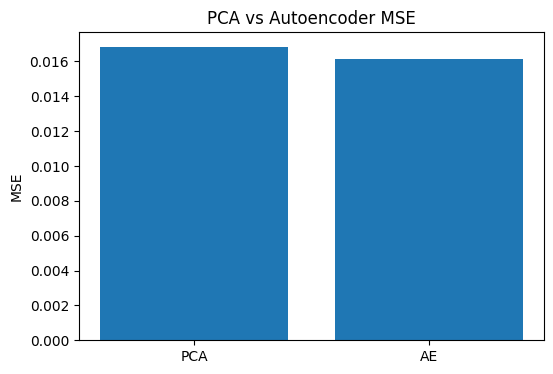

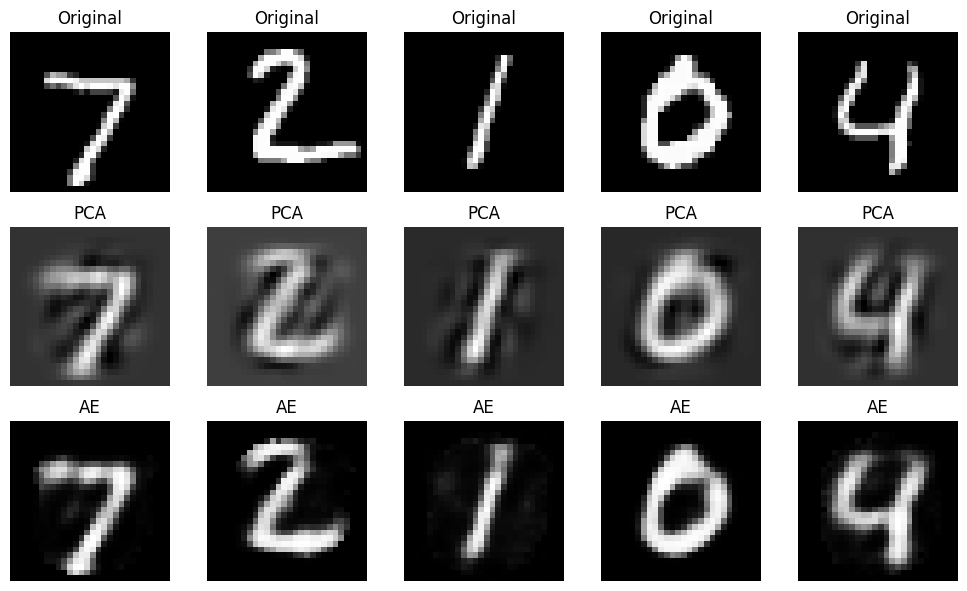

In [ ]:
#PCA ON AutoEncoders

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ==========================================================
# 1. LOAD DATA
# ==========================================================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(60000, 784)
x_test  = x_test.reshape(10000, 784)

# ==========================================================
# 2. PCA MODEL
# ==========================================================
pca = PCA(n_components=32)

# Reduce dimension
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)

# Reconstruct image
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# PCA Error
pca_mse = mean_squared_error(
    x_test.flatten(),
    x_test_pca_recon.flatten()
)

print("PCA MSE =", round(pca_mse,6))

# ==========================================================
# 3. AUTOENCODER MODEL
# ==========================================================
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(32, activation='relu')(input_img)

# Decoder
decoded = Dense(784, activation='sigmoid')(encoded)

# Model
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# Train
history = autoencoder.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Reconstruct image
x_test_ae_recon = autoencoder.predict(x_test)

# AE Error
ae_mse = mean_squared_error(
    x_test.flatten(),
    x_test_ae_recon.flatten()
)

print("AE MSE  =", round(ae_mse,6))

# ==========================================================
# 4. COMPARISON GRAPH
# ==========================================================
models = ["PCA", "AE"]
errors = [pca_mse, ae_mse]

plt.figure(figsize=(6,4))
plt.bar(models, errors)
plt.title("PCA vs Autoencoder MSE")
plt.ylabel("MSE")
plt.show()

# ==========================================================
# 5. IMAGE COMPARISON
# ==========================================================
plt.figure(figsize=(10,6))

for i in range(5):

    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # PCA
    plt.subplot(3,5,i+6)
    plt.imshow(x_test_pca_recon[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis("off")

    # AE
    plt.subplot(3,5,i+11)
    plt.imshow(x_test_ae_recon[i].reshape(28,28), cmap='gray')
    plt.title("AE")
    plt.axis("off")

plt.tight_layout()
plt.show()

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3628 - val_loss: 0.2232
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2092 - val_loss: 0.1726
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1682 - val_loss: 0.1568
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1550 - val_loss: 0.1464
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1461 - val_loss: 0.1414
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1412 - val_loss: 0.1370
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1376 - val_loss: 0.1341
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1342 - val_loss: 0.1304
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1309 - val_loss: 0.1279
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1290 - val_loss: 0.1266
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1267 - val_loss: 0.1244
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 

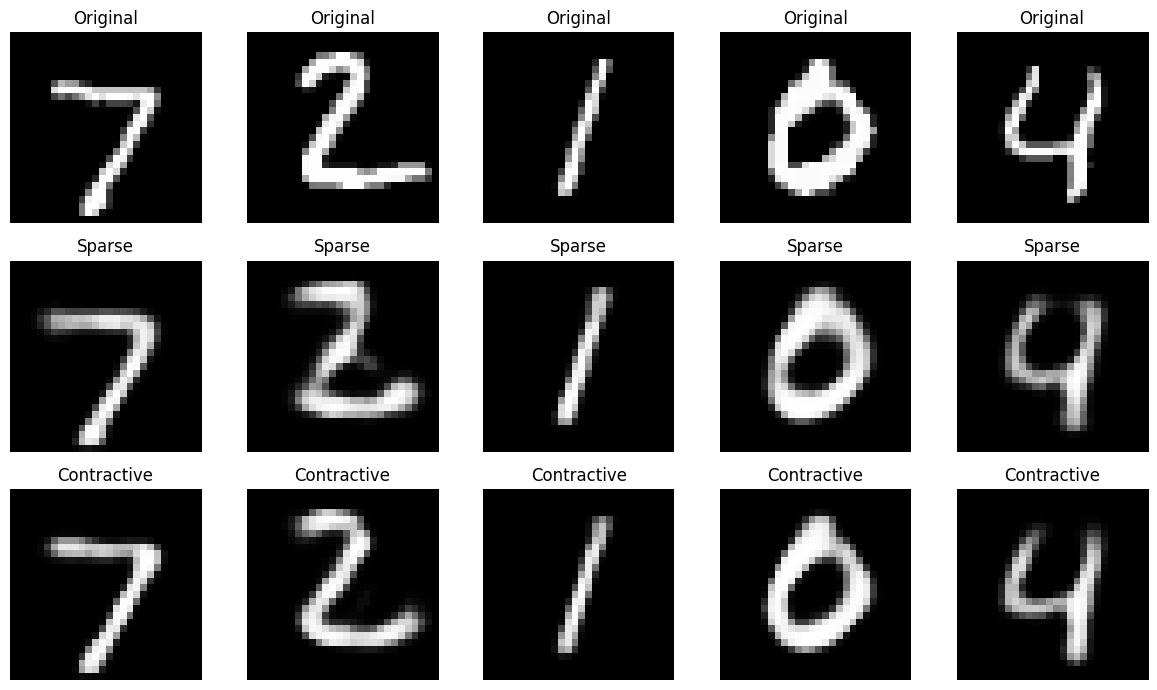

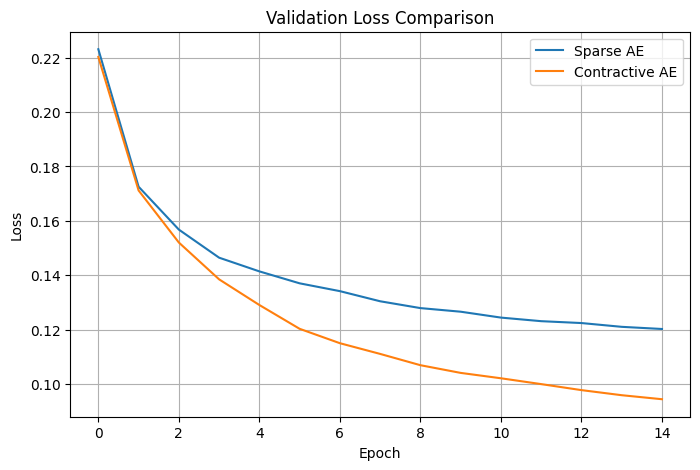

In [ ]:
# SPARSE AE vs CONTRACTIVE AE

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from sklearn.metrics import mean_squared_error

# ==========================================================
# 1. LOAD DATA
# ==========================================================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train.reshape(60000, 784)
x_test  = x_test.reshape(10000, 784)

# ==========================================================
# 2. SPARSE AUTOENCODER (DEEPER MODEL)
# ==========================================================
input1 = Input(shape=(784,))

x = Dense(256, activation='relu')(input1)
x = Dense(128, activation='relu')(x)

encoded1 = Dense(
    64,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-5)
)(x)

x = Dense(128, activation='relu')(encoded1)
x = Dense(256, activation='relu')(x)

decoded1 = Dense(784, activation='sigmoid')(x)

sparse_ae = Model(input1, decoded1)

sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

history1 = sparse_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

recon1 = sparse_ae.predict(x_test)

mse1 = mean_squared_error(x_test.flatten(), recon1.flatten())

print("\nSparse AE MSE =", round(mse1,6))

# ==========================================================
# 3. CONTRACTIVE AE (BETTER MODEL)
# ==========================================================
input2 = Input(shape=(784,))

x = Dense(256, activation='relu')(input2)
x = Dense(128, activation='relu')(x)

encoded2 = Dense(64, activation='sigmoid')(x)

x = Dense(128, activation='relu')(encoded2)
x = Dense(256, activation='relu')(x)

decoded2 = Dense(784, activation='sigmoid')(x)

contractive_ae = Model(input2, decoded2)

contractive_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

history2 = contractive_ae.fit(
    x_train, x_train,
    epochs=15,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

recon2 = contractive_ae.predict(x_test)

mse2 = mean_squared_error(x_test.flatten(), recon2.flatten())

print("Contractive AE MSE =", round(mse2,6))

# ==========================================================
# 4. IMAGE COMPARISON
# ==========================================================
plt.figure(figsize=(12,7))

for i in range(5):

    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Sparse
    plt.subplot(3,5,i+6)
    plt.imshow(recon1[i].reshape(28,28), cmap='gray')
    plt.title("Sparse")
    plt.axis("off")

    # Contractive
    plt.subplot(3,5,i+11)
    plt.imshow(recon2[i].reshape(28,28), cmap='gray')
    plt.title("Contractive")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# 5. LOSS GRAPH
# ==========================================================
plt.figure(figsize=(8,5))
plt.plot(history1.history['val_loss'], label='Sparse AE')
plt.plot(history2.history['val_loss'], label='Contractive AE')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()